In [1]:
import pandas as pd  #엑셀처럼다루기
import numpy as np  #숫자계싼
import matplotlib.pyplot as plt #그래프
import seaborn as sns  #예쁜그래프
!pip install wordcloud  # ! - 주피터에서 명령어쓰기
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False    #그래프에서 한글 안 깨지게

movies_df = pd.read_csv('../datasets/netflix_movies_detailed_up_to_2025.csv')
tv_shows_df = pd.read_csv('../datasets/netflix_tv_shows_detailed_up_to_2025.csv')
movies_df.shape #데이터가 얼마나 큰지 보는 코드
tv_shows_df.shape  #데이터가 얼마나 큰지 보는 코드


(16000, 16)

In [4]:
netflix_df = pd.concat([movies_df,tv_shows_df], ignore_index=True)
netflix_df.shape


(32000, 18)

In [5]:
netflix_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       32000 non-null  int64  
 1   type          32000 non-null  str    
 2   title         32000 non-null  str    
 3   director      20903 non-null  str    
 4   cast          30639 non-null  str    
 5   country       29737 non-null  str    
 6   date_added    32000 non-null  str    
 7   release_year  32000 non-null  int64  
 8   rating        32000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        30919 non-null  str    
 11  language      32000 non-null  str    
 12  description   28662 non-null  str    
 13  popularity    32000 non-null  float64
 14  vote_count    32000 non-null  int64  
 15  vote_average  32000 non-null  float64
 16  budget        16000 non-null  float64
 17  revenue       16000 non-null  float64
dtypes: float64(5), int64(3), object(1), s

In [10]:
netflix_df['director'] = netflix_df['director'].fillna('No Director')
netflix_df['cast'] = netflix_df['cast'].fillna('No Cast')
netflix_df['country'] = netflix_df['country'].fillna('Unknown')

한국 컨텐츠 수2174


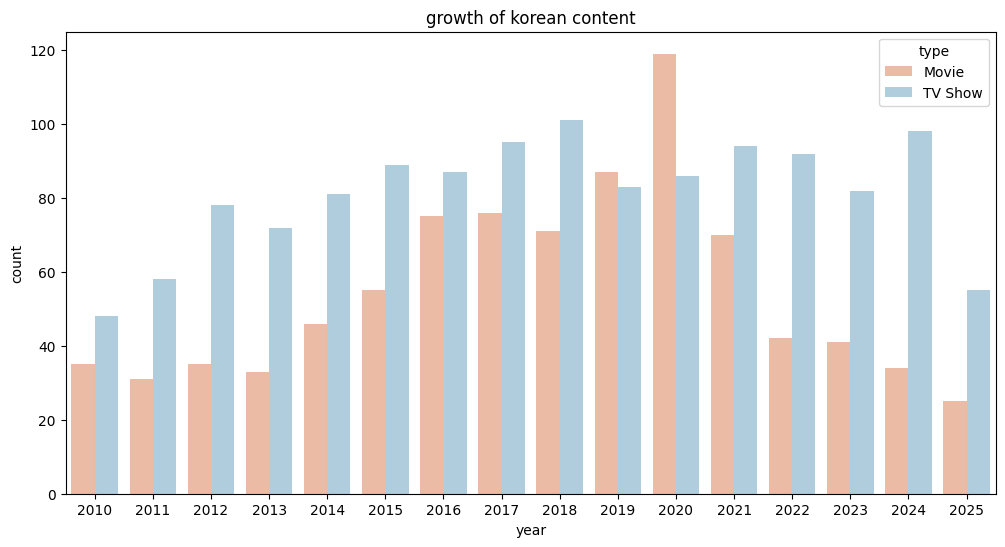

In [11]:
#날짜 데이터 변환(년도로)
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], errors='coerce')
netflix_df['year_added'] = netflix_df['date_added'].dt.year
#한국 컨텐츠 그래프
korean_content = netflix_df[netflix_df['country'].str.contains('South Korea', na=False)]
print(f'한국 컨텐츠 수{len(korean_content)}')
plt.figure(figsize=(12,6))
sns.countplot(x='year_added', data=korean_content, hue='type', palette='RdBu')
plt.title('growth of korean content')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

C:\Users\301-23\AppData\Local\Temp\ipykernel_25480\1729504877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')


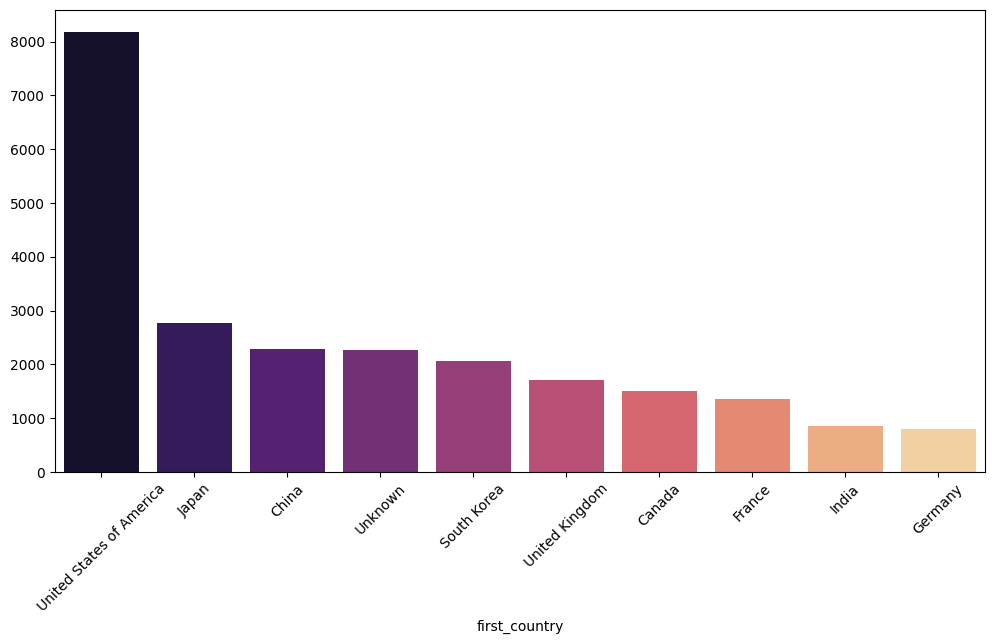

In [14]:
# 국가 데이터가 콤마로 구분된경우 첫번째 국가만 사용
netflix_df['first_country'] = netflix_df['country'].apply(lambda x: x.split(',')[0])
plt.figure(figsize=(12,6))
top_countries = netflix_df['first_country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
plt.xticks(rotation=45)
plt.show()

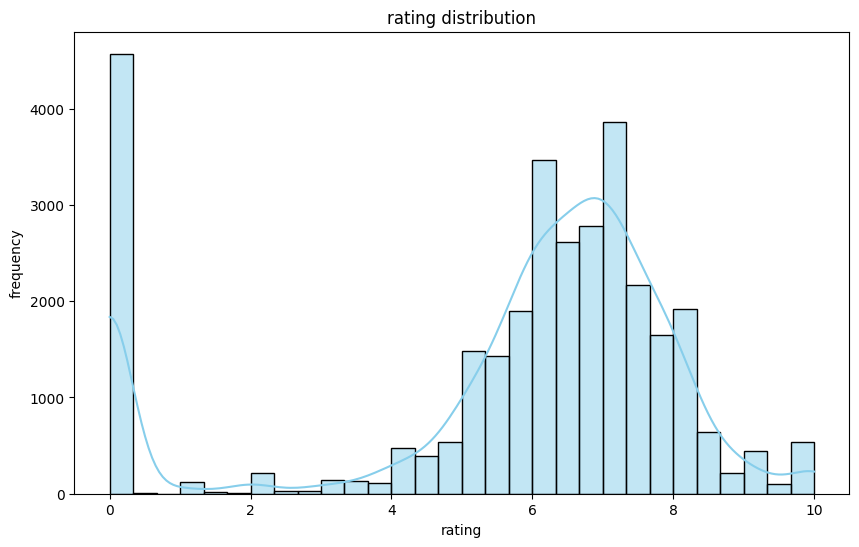

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(netflix_df['rating'], bins=30, kde=True, color='skyblue')
plt.title('rating distribution')
plt.xlabel('rating')
plt.ylabel('frequency')
plt.show()

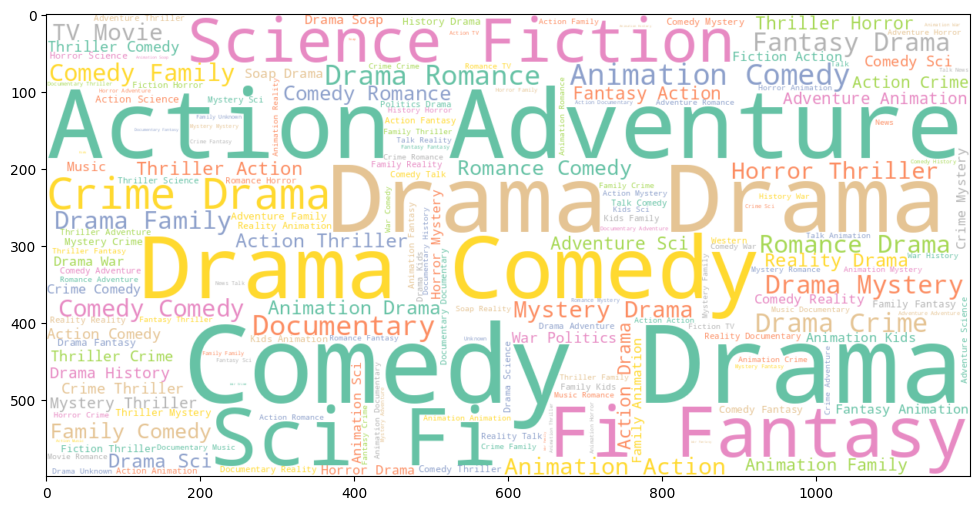

In [17]:
from wordcloud import WordCloud
text = str(list(netflix_df['genres'].dropna())).replace("'","")
len(text)
wordcloud = WordCloud(background_color='white'
                      ,width=1200,height=600,colormap='Set2').generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

In [18]:
#글로벌 인기 콘텐츠 top 10
top_10_pop = netflix_df.sort_values(by=['popularity'], ascending=False).head(10)
top_10_pop[['title','type','release_year','popularity','country']]
top_10_pop.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue,year_added,first_country
21000,63770,TV Show,The Late Show with Stephen Colbert,No Director,Stephen Colbert,United States of America,2015-09-08,2015,6.493,1 Seasons,"Comedy, Talk",en,Stephen Colbert brings his signature satire an...,6421.923,288,6.493,NaN,NaN,2015,United States of America
20000,59941,TV Show,The Tonight Show Starring Jimmy Fallon,No Director,"Jimmy Fallon, Steve Higgins, IrishCGM",United States of America,2014-02-17,2014,5.800,1 Seasons,"Comedy, Talk",en,After Jay Leno's second retirement from the pr...,4925.253,321,5.800,NaN,NaN,2014,United States of America
15000,950396,Movie,The Gorge,Scott Derrickson,"Miles Teller, Anya Taylor-Joy, Sigourney Weave...",United States of America,2025-02-13,2025,7.785,NaN,"Romance, Science Fiction, Thriller",en,Two highly trained operatives grow close from ...,3876.006,1572,7.785,0.0,0.0,2025,United States of America
18000,65701,TV Show,Good Mythical Morning,No Director,"Link Neal, Rhett McLaughlin",United States of America,2012-01-09,2012,6.800,1 Seasons,Comedy,en,"Two ""Internetainers"" (Rhett & Link) go far out...",3414.466,67,6.800,NaN,NaN,2012,United States of America
15001,1126166,Movie,Flight Risk,Mel Gibson,"Mark Wahlberg, Michelle Dockery, Topher Grace,...",United States of America,2025-01-22,2025,6.000,NaN,"Action, Thriller, Crime",en,A U.S. Marshal escorts a government witness to...,3320.616,350,6.000,25000000.0,40420193.0,2025,United States of America
24000,81329,TV Show,Chronicles of the Sun,No Director,"Mélanie Maudran, Moïse Santamaria",France,2018-08-27,2018,6.800,1 Seasons,Soap,fr,Claire is surprised when she gets arrested for...,2987.485,117,6.800,NaN,NaN,2018,France
30000,257064,TV Show,Volta por Cima,"Caetano Caruso, André Câmara","Jéssica Ellen, Fabrício Boliveira, Milhem Cort...",Brazil,2024-09-30,2024,5.781,1 Seasons,"Soap, Drama, Comedy",pt,NaN,2885.720,16,5.781,NaN,NaN,2024,Brazil
30001,257048,TV Show,She's the One,"Jeferson De, Mayara Aguiar, Tande Bressane","Duda Santos, Pedro Novaes, Maisa Silva, Fábio ...",Brazil,2024-11-04,2024,8.100,1 Seasons,"Soap, Drama",pt,"Beatriz Dourado, a young black woman marked by...",2862.872,9,8.100,NaN,NaN,2024,Brazil
14000,762509,Movie,Mufasa: The Lion King,Barry Jenkins,"Aaron Pierre, Kelvin Harrison, Jr., Tiffany Bo...",United States of America,2024-12-18,2024,7.467,NaN,"Adventure, Family, Animation",en,"Mufasa, a cub lost and alone, meets a sympathe...",2643.627,1497,7.467,200000000.0,700197856.0,2024,United States of America
30004,237478,TV Show,Crazy About You,"Isabella Teixeira, Noa Bressane, Philippe Barc...","Gabz, Agatha Moreira, Chay Suede, Nicolas Prat...",Brazil,2024-09-09,2024,5.200,1 Seasons,"Soap, Drama, Mystery",pt,The story begins with the ambiguous relationsh...,2442.243,16,5.200,NaN,NaN,2024,Brazil


C:\Users\301-23\AppData\Local\Temp\ipykernel_25480\676857895.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='popularity', y='title', data=korean_10_pop, palette='RdBu_r')


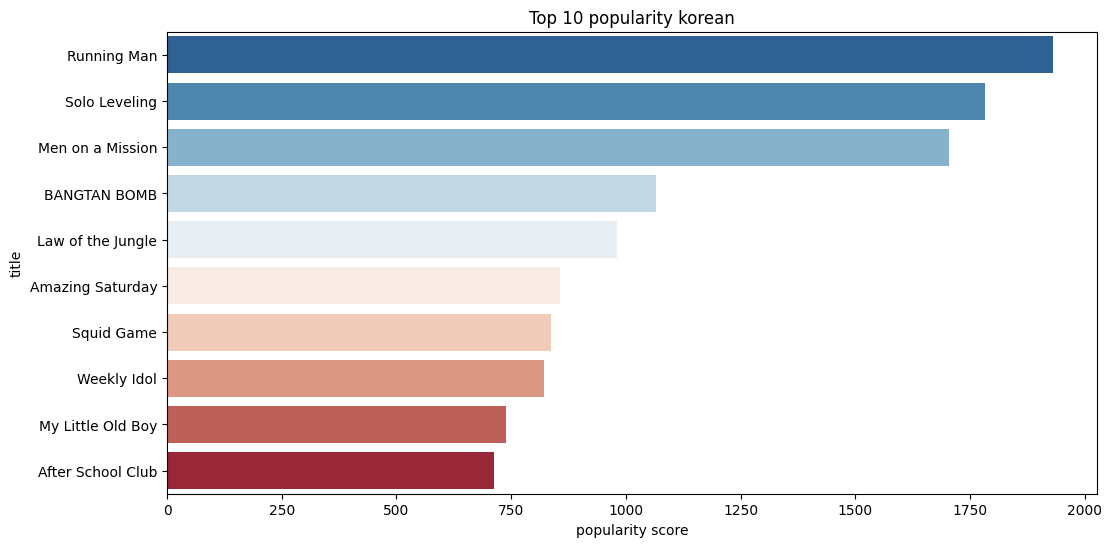

In [20]:
#한국 top 10
korean_pop = netflix_df[netflix_df['country'].str.contains('South Korea', na=False)]
korean_10_pop = korean_pop.sort_values(by='popularity', ascending=False).head(10)
korean_10_pop[['title','type','release_year','popularity','country']]
korean_10_pop.head(10)
plt.figure(figsize=(12,6))
sns.barplot(x='popularity', y='title', data=korean_10_pop, palette='RdBu_r')
plt.title('Top 10 popularity korean')
plt.xlabel('popularity score')
plt.show()

C:\Users\301-23\AppData\Local\Temp\ipykernel_25480\2833703390.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='popularity', data=comparison, palette=['grey', 'red'])


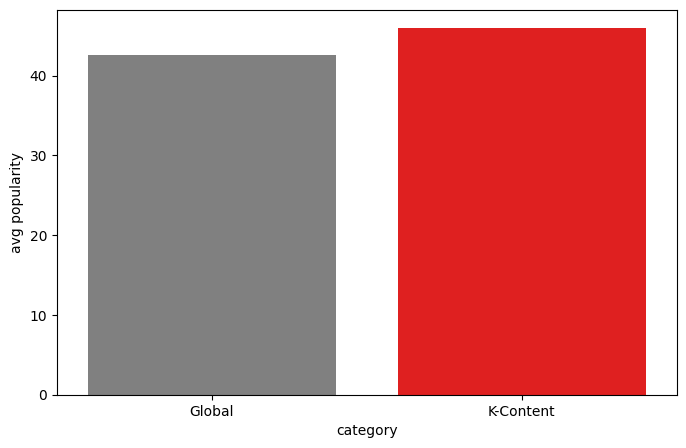

In [22]:
# 전체 콘텐츠와 한국 콘텐츠 평균인기 비교
avg_popularity_all = netflix_df['popularity'].mean()
avg_popularity_korea = netflix_df[
    netflix_df['country'].str.contains('South Korea', na=False)]['popularity'].mean()
comparison = pd.DataFrame({
    'category':['Global', 'K-Content']
    ,'popularity':[avg_popularity_all, avg_popularity_korea]
})
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='popularity', data=comparison, palette=['grey', 'red'])
plt.ylabel('avg popularity')
plt.show()

In [26]:
#평점이 8점(vote_average)이상 한국영화는 몇편?  챗지피티

high_rated_korea_movie = netflix_df[
    (netflix_df['vote_average'] >= 8) &
    (netflix_df['country'].str.contains('South Korea', na=False)) &
    (netflix_df['type'] == 'Movie')
]

print("평점 8점 이상 한국 영화 수:", len(high_rated_korea_movie))



평점 8점 이상 한국 영화 수: 64


In [31]:
#평점이 8점 이상 영화에서 top 10 출력(popularity)기준 정렬
# 평점 8점 이상 + 영화만 필터링   챗지피티
high_korea = netflix_df[
    (netflix_df['vote_average'] >= 8) &
    (netflix_df['country'].str.contains('South Korea', na=False)) &
    (netflix_df['type'] == 'Movie')
]

top10_korea = high_korea.sort_values(
    by='popularity',
    ascending=False
).head(10)

top10_korea[['title', 'type', 'vote_average', 'popularity', 'release_year']]



,title,type,vote_average,popularity,release_year
9002,Parasite,Movie,8.500,130.550,2019
15043,Squid Game: Making Season 2,Movie,8.500,107.996,2025
8009,Youthful Older Sister,Movie,8.200,87.685,2018
12014,20th Century Girl,Movie,8.200,87.326,2022
6012,The Handmaiden,Movie,8.200,76.601,2016
7018,Reunion Goals: The Beginning,Movie,8.500,68.826,2017
7042,Along with the Gods: The Two Worlds,Movie,8.075,47.967,2017
8034,Along with the Gods: The Last 49 Days,Movie,8.078,46.532,2018
10032,"Miraculous World: New York, United HeroeZ",Movie,8.083,37.630,2020
11092,Dangerous Younger Cousin,Movie,10.000,29.801,2021


In [32]:
#평점이 8점(vote_average)이상 한국영화는 몇편? 샘이한거
korean_movies = movies_df[movies_df['country'].str.contains('South Korea', na=False)].copy()
high_korean = korean_movies[korean_movies['vote_average'] >= 8]
print(f'8점 이상 영화는 총 {len(high_korean)}')

8점 이상 영화는 총 64


In [33]:
#평점이 8점 이상 영화에서 top 10 출력(popularity)기준 정렬
# 평점 8점 이상 + 영화만 필터링   샘이한거
top = high_korean.sort_values(by='popularity', ascending=False).head(10)[['title', 'popularity']]
top
# sort values(~ ascending) : popularity기준으로 내림차순ㄴ정렬, head 10, 위에서 10줄만
#title, populr 열만 봉주세요.

,title,popularity
9002,Parasite,130.550
15043,Squid Game: Making Season 2,107.996
8009,Youthful Older Sister,87.685
12014,20th Century Girl,87.326
6012,The Handmaiden,76.601
7018,Reunion Goals: The Beginning,68.826
7042,Along with the Gods: The Two Worlds,47.967
8034,Along with the Gods: The Last 49 Days,46.532
10032,"Miraculous World: New York, United HeroeZ",37.630
11092,Dangerous Younger Cousin,29.801


In [36]:
#2017년 이후 공개된 한국 영화중 ROI(수익률)가장 높은 10편
# 예산, 수익 있는 한국 영화만 필터
k_movies = korean_movies[
    (korean_movies['budget'] > 0) &
    (korean_movies['revenue'] > 0)
].copy()

# ROI 계산
k_movies['roi'] = (k_movies['revenue'] - k_movies['budget']) / k_movies['budget']

# 2018년 이후 + 결측치 제거
recent_kor = k_movies[
    (k_movies['release_year'] >= 2018) &
    (k_movies['roi'].notna())
]

# ROI 기준 TOP10
top10_roi = recent_kor.sort_values(
    by='roi',
    ascending=False
).head(10)[['title', 'roi']]

top10_roi



,title,roi
9002,Parasite,21.669346
9190,Extreme Job,14.351257
12064,The Roundup,12.311409
9279,EXIT,5.380993
8034,Along with the Gods: The Last 49 Days,5.163399
8041,The Witch: Part 1. The Subversion,3.425509
8854,Dark Figure of Crime,3.133428
9003,"The Gangster, the Cop, the Devil",2.965442
9150,Ashfall,2.464516
8241,The Great Battle,2.119826
